In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt


In [2]:
def softmax(x, axis=-1):
    x_shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]

    # Step 1: QK^T  shape: (batch, heads, seq, seq)
    scores = np.matmul(Q, K.transpose(0, 1, 3, 2))

    # Step 2: Scale
    scores = scores / math.sqrt(d_k)

    # Step 3: Apply causal mask (True = mask out -> -inf)
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)

    # Step 4: Softmax
    attention_weights = softmax(scores, axis=-1)

    # Step 5: Weighted sum of values
    output = np.matmul(attention_weights, V)

    return output, attention_weights


In [4]:
def build_causal_mask(seq_len):
    # Upper triangle = True (future positions, masked out)
    return np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)


In [5]:
def multi_head_attention(X, W_q, W_k, W_v, W_o, num_heads, mask=None):
    batch_size, seq_len, d_model = X.shape
    d_k = d_model // num_heads

    # Linear projections
    Q = X @ W_q
    K = X @ W_k
    V = X @ W_v

    # Split into heads: (B, S, d_model) -> (B, H, S, d_k)
    def split_heads(t):
        B, S, _ = t.shape
        return t.reshape(B, S, num_heads, d_k).transpose(0, 2, 1, 3)

    Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

    # Scaled dot-product attention (4D)
    attn_out, attn_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

    # Concatenate heads: (B, H, S, d_k) -> (B, S, d_model)
    concat = attn_out.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, d_model)

    # Output projection
    output = concat @ W_o

    return output, attn_weights


In [6]:
np.random.seed(42)

BATCH_SIZE = 2
NUM_HEADS  = 4
SEQ_LEN    = 6
D_K        = 64
D_V        = 64

Q = np.random.randn(BATCH_SIZE, NUM_HEADS, SEQ_LEN, D_K)
K = np.random.randn(BATCH_SIZE, NUM_HEADS, SEQ_LEN, D_K)
V = np.random.randn(BATCH_SIZE, NUM_HEADS, SEQ_LEN, D_V)

causal_mask = build_causal_mask(SEQ_LEN)

# Without mask
out_no_mask, w_no_mask = scaled_dot_product_attention(Q, K, V)
print("Without Mask:")
print(f"  Output shape  : {out_no_mask.shape}")
print(f"  Weights shape : {w_no_mask.shape}")
print(f"  Row sum check : {w_no_mask[0,0,0,:].sum():.6f}")

# With causal mask
out_masked, w_masked = scaled_dot_product_attention(Q, K, V, mask=causal_mask)
print("\nWith Causal Mask:")
print(f"  Output shape  : {out_masked.shape}")
np.set_printoptions(precision=4, suppress=True)
print("  Weights [batch=0, head=0]:")
print(w_masked[0, 0])


Without Mask:
  Output shape  : (2, 4, 6, 64)
  Weights shape : (2, 4, 6, 6)
  Row sum check : 1.000000

With Causal Mask:
  Output shape  : (2, 4, 6, 64)
  Weights [batch=0, head=0]:
[[1.     0.     0.     0.     0.     0.    ]
 [0.1302 0.8698 0.     0.     0.     0.    ]
 [0.1962 0.1885 0.6152 0.     0.     0.    ]
 [0.1549 0.4073 0.1857 0.2521 0.     0.    ]
 [0.0921 0.2719 0.1779 0.3458 0.1122 0.    ]
 [0.081  0.296  0.3769 0.0811 0.0484 0.1166]]


In [7]:
np.random.seed(0)

B       = 2
S       = 8
D_MODEL = 128
H       = 4

X = np.random.randn(B, S, D_MODEL)

scale = np.sqrt(1.0 / D_MODEL)
W_q = np.random.randn(D_MODEL, D_MODEL) * scale
W_k = np.random.randn(D_MODEL, D_MODEL) * scale
W_v = np.random.randn(D_MODEL, D_MODEL) * scale
W_o = np.random.randn(D_MODEL, D_MODEL) * scale

mask = build_causal_mask(S)

mha_out, mha_weights = multi_head_attention(X, W_q, W_k, W_v, W_o, H, mask=mask)

print(f"Input shape  : {X.shape}")
print(f"Output shape : {mha_out.shape}")
print(f"Weights shape: {mha_weights.shape}")
print(f"Row sums all 1.0: {np.allclose(mha_weights.sum(axis=-1), 1.0)}")


Input shape  : (2, 8, 128)
Output shape : (2, 8, 128)
Weights shape: (2, 4, 8, 8)
Row sums all 1.0: True


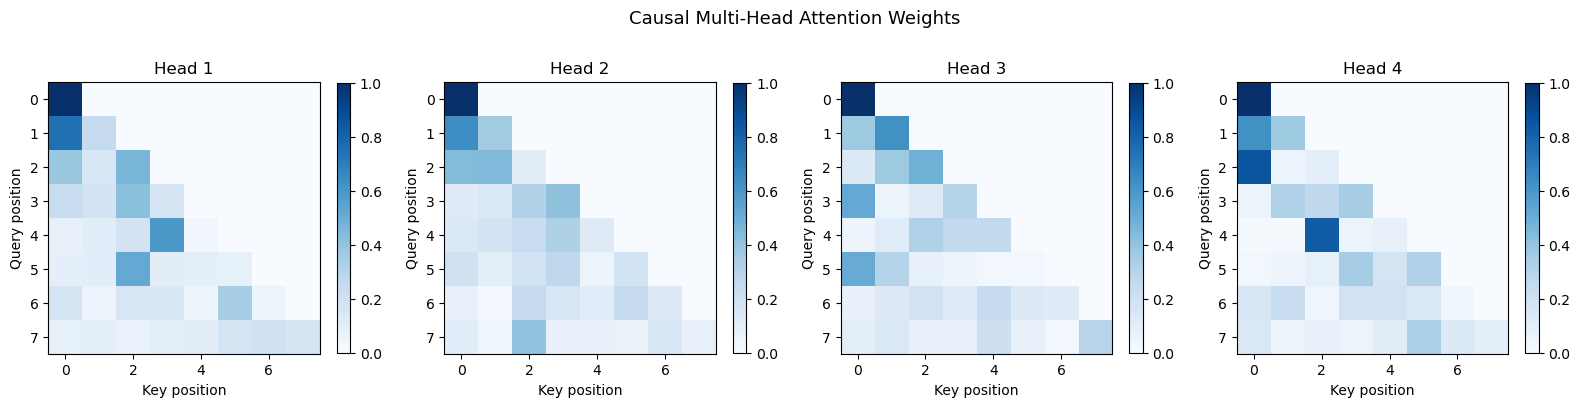

In [8]:
fig, axes = plt.subplots(1, H, figsize=(4*H, 4))
for h, ax in enumerate(axes):
    im = ax.imshow(mha_weights[0, h], vmin=0, vmax=1, cmap="Blues")
    ax.set_title(f"Head {h+1}")
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Causal Multi-Head Attention Weights", fontsize=13)
plt.tight_layout()
plt.savefig("attention_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
